21-7-2026

In [1]:
#importing the reuqired libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\esair\Downloads\retail_sales_dataset.csv")
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150


In [2]:
product_by_age=df.groupby(['Gender','Age'])['Total Amount'].sum().reset_index()
product_by_age

,Gender,Age,Total Amount
0,Female,18,7940
1,Female,19,7335
2,Female,20,5175
3,Female,21,5400
4,Female,22,5425
...,...,...,...
89,Male,60,3930
90,Male,61,3890
91,Male,62,5060
92,Male,63,8045


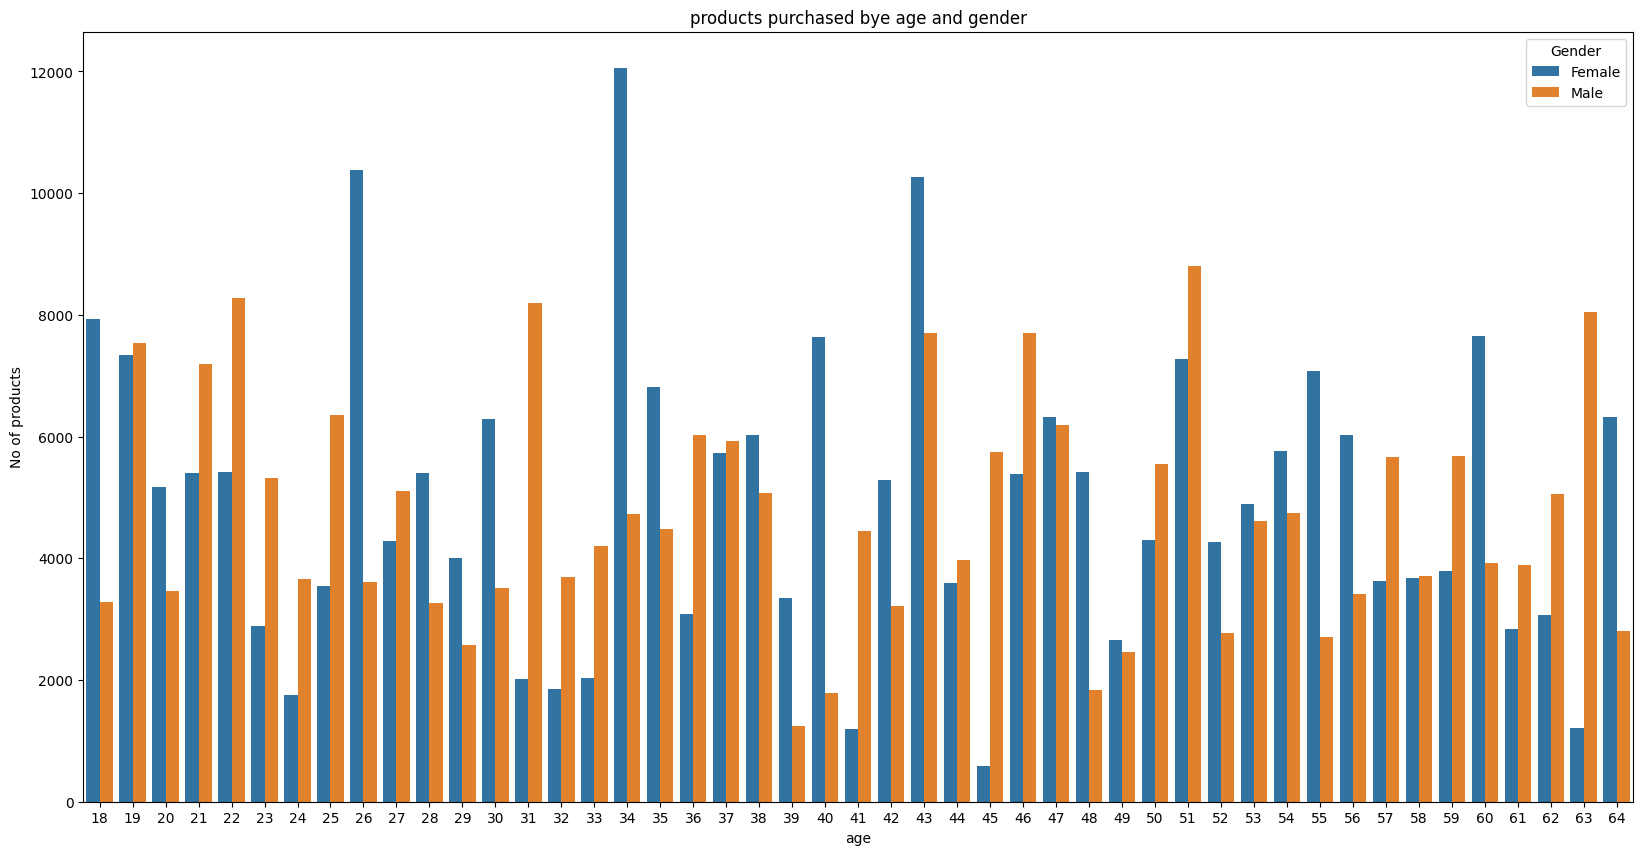

In [3]:
plt.figure(figsize=(20,10))
sns.barplot(data=product_by_age,x='Age',y='Total Amount',hue='Gender')
plt.title("products purchased bye age and gender")
plt.xlabel("age")
plt.ylabel("No of products")
plt.show()

In [4]:
beauty=df[df['Product Category']=='Beauty']
beauty_by_age=beauty.groupby(['Age','Gender'])['Product Category'].count().reset_index()
print(beauty_by_age)

    Age  Gender  Product Category
0    18  Female                 5
1    18    Male                 4
2    19  Female                 4
3    19    Male                 3
4    20  Female                 5
..  ...     ...               ...
83   62    Male                 4
84   63  Female                 2
85   63    Male                 1
86   64  Female                 4
87   64    Male                 6

[88 rows x 3 columns]


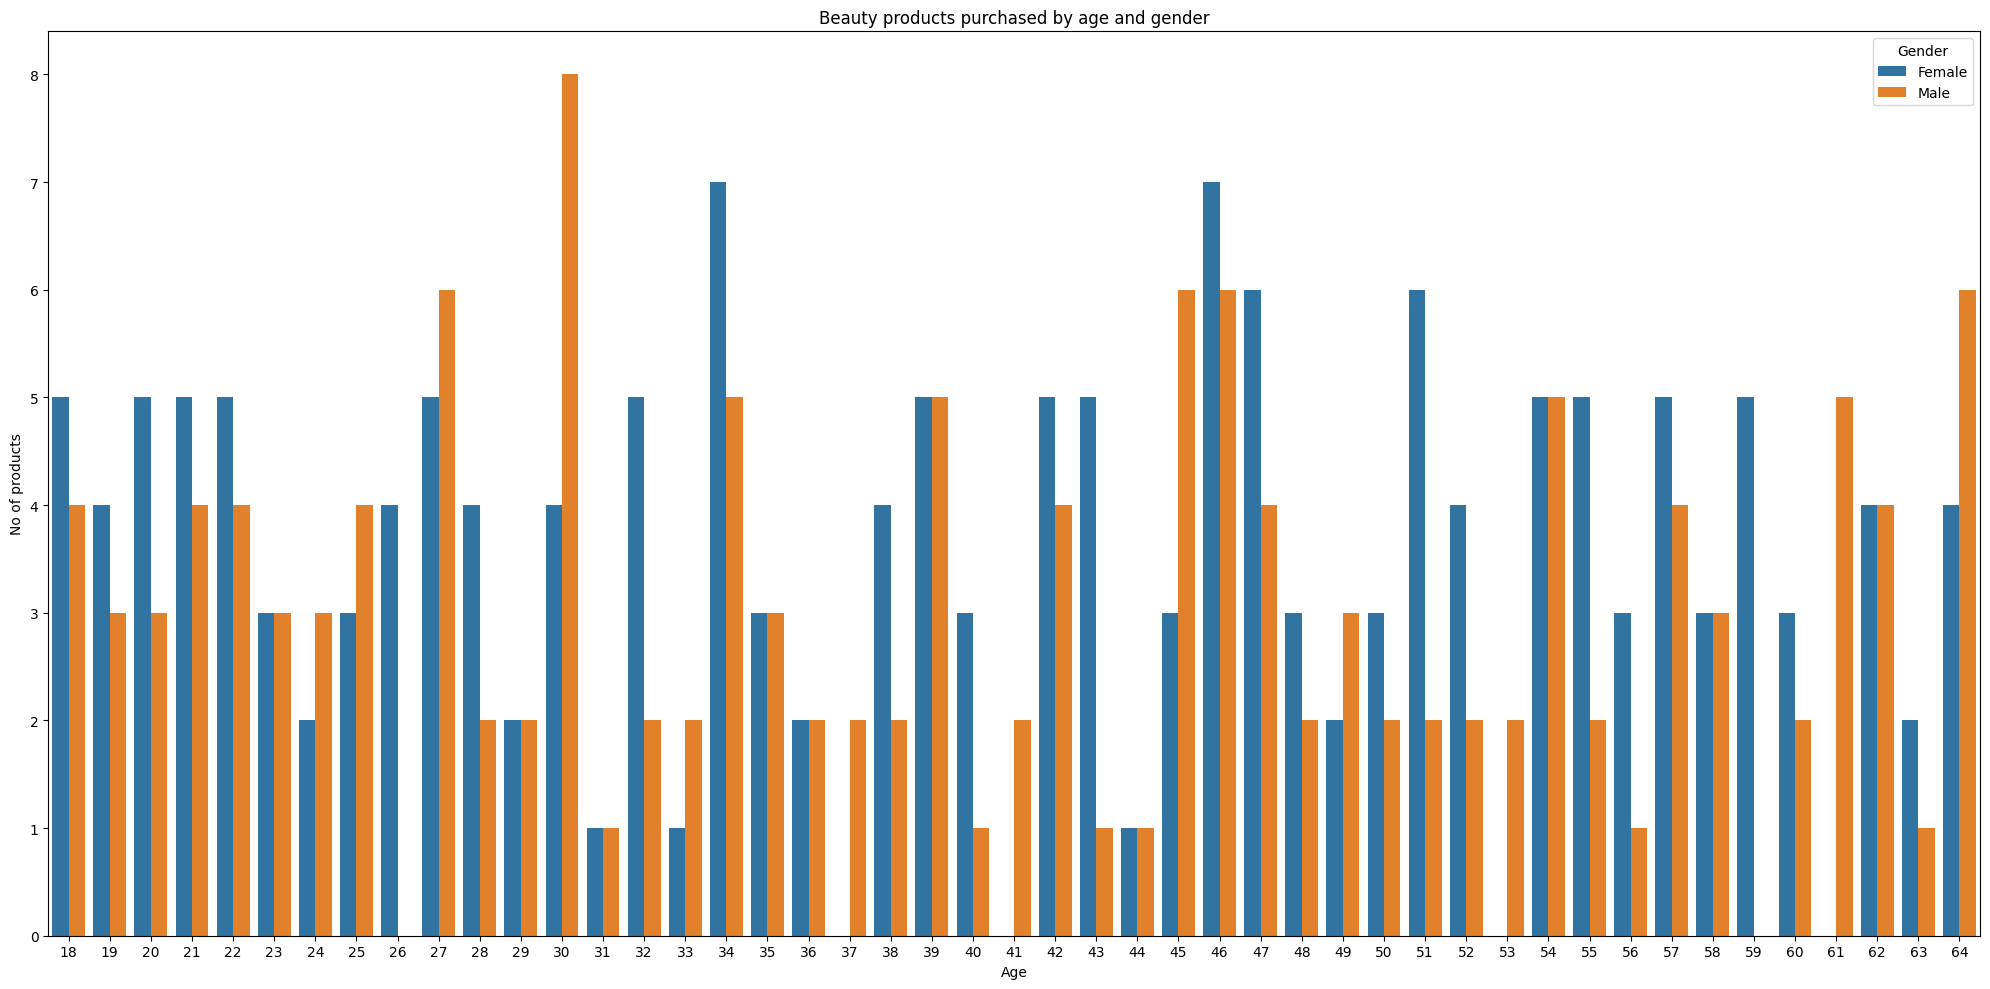

In [5]:
#ploting the graph or chart
plt.figure(figsize=(20,10))
sns.barplot(data=beauty_by_age,x='Age',y='Product Category',hue='Gender')
plt.title("Beauty products purchased by age and gender")
plt.xlabel("Age")
plt.ylabel("No of products")
plt.tight_layout()
plt.show()

22-7-26

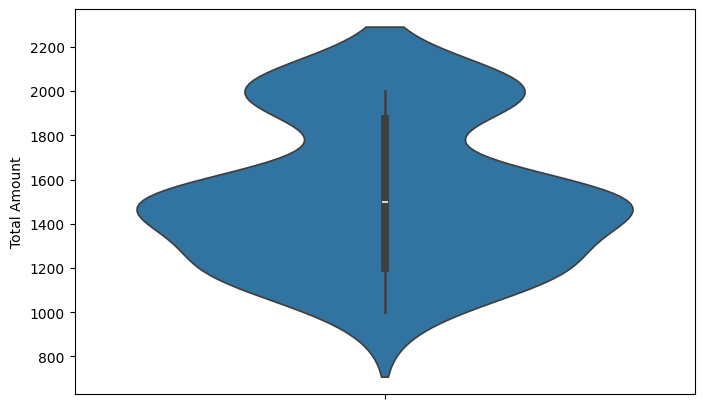

In [6]:
#which coutmer has spent the most money on beauty products
beauty_by_age=beauty.groupby(['Customer ID'])['Total Amount'].sum().reset_index()

top10 = beauty_by_age.sort_values(by='Total Amount', ascending=False).head(50)
plt.figure(figsize=(8,5))
sns.violinplot(data=top10,y='Total Amount')
plt.xticks(rotation=90)
plt.show()


23-7-2026


In [7]:
clothing=df[df['Product Category']=='Clothing']
clothing_by_gender=clothing.groupby(['Gender','Total Amount'])['Quantity'].sum().reset_index()
print(clothing_by_gender)

    Gender  Total Amount  Quantity
0   Female            25        12
1   Female            30         8
2   Female            50        24
3   Female            60        16
4   Female            75        21
5   Female            90        39
6   Female           100        54
7   Female           120        32
8   Female           150        24
9   Female           200        24
10  Female           300        10
11  Female           500         8
12  Female           600        12
13  Female           900        30
14  Female          1000        14
15  Female          1200        52
16  Female          1500        21
17  Female          2000        40
18    Male            25         9
19    Male            30         5
20    Male            50        34
21    Male            60        18
22    Male            75        24
23    Male            90         9
24    Male           100        60
25    Male           120        44
26    Male           150        27
27    Male          

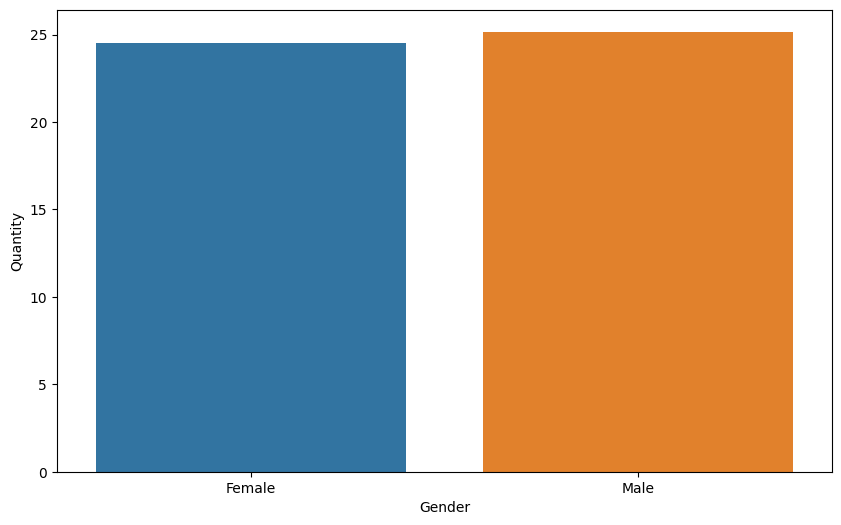

In [8]:
plt.figure(figsize=(10,6))
sns.barplot(data=clothing_by_gender,x='Gender',y='Quantity',errorbar=None,hue='Gender')
plt.show()

    Gender  Total Amount  Transaction ID  \
0   Female            25           13740   
1   Female            30           10411   
2   Female            50           28547   
3   Female            60           12069   
4   Female            75           14562   
5   Female            90           13009   
6   Female           100           25208   
7   Female           120           11570   
8   Female           150           11364   
9   Female           200           15833   
10  Female           300           14220   
11  Female           500           12104   
12  Female           600            7317   
13  Female           900           16937   
14  Female          1000           12886   
15  Female          1200           13675   
16  Female          1500           10148   
17  Female          2000           10156   
18    Male            25           12229   
19    Male            30           16399   
20    Male            50           31468   
21    Male            60        

<Axes: ylabel='Total Amount'>

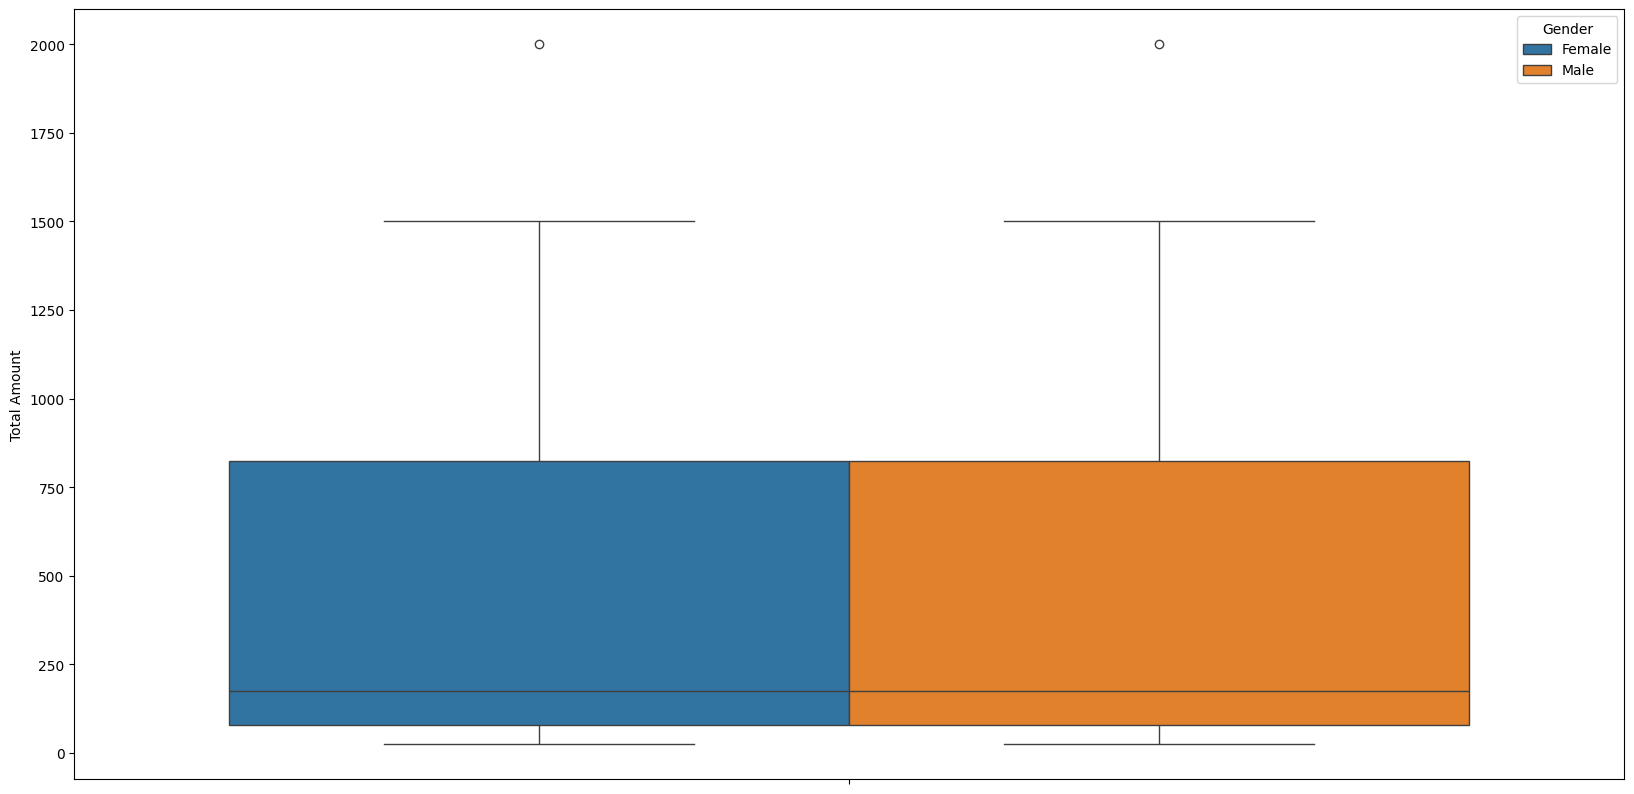

In [9]:
gender=df.groupby(['Gender','Total Amount']).sum().reset_index()
print(gender)
plt.figure(figsize=(20,10))
sns.boxplot(data=gender,y='Total Amount',hue='Gender')

violinplot


C:\Users\esair\AppData\Local\Temp\ipykernel_23876\1515206651.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=gender,y=marks,inner='quart',split=False,palette="coolwarm",legend=False)


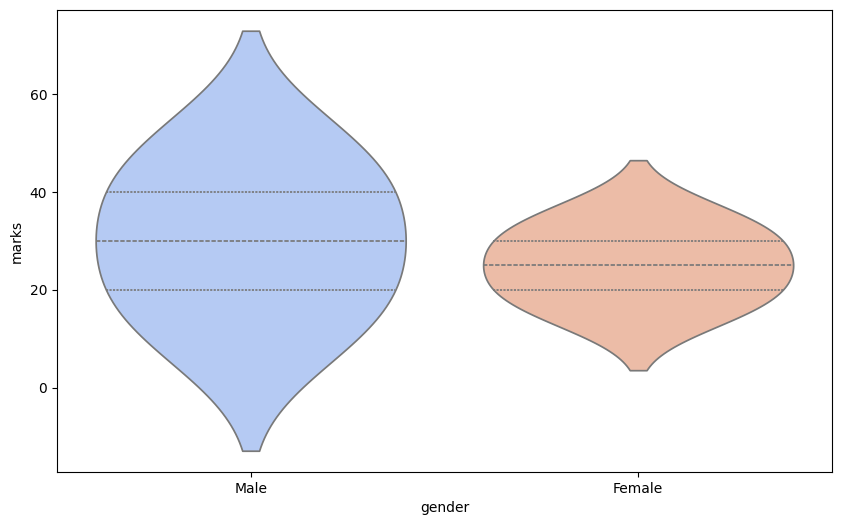

In [10]:
gender = ["Male","Male","Male","Male","Male",
          "Female","Female","Female","Female","Female"]

marks = [10,20,30,40,50,15,20,25,30,35]
plt.figure(figsize=(10,6))
sns.violinplot(x=gender,y=marks,inner='quart',split=False,palette="coolwarm",legend=False)
plt.xlabel('gender')
plt.ylabel('marks')
plt.show()


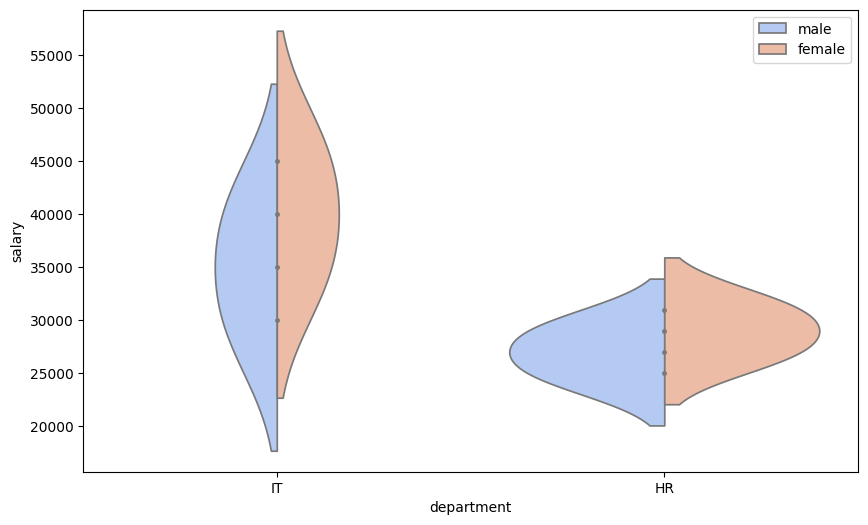

In [ ]:
import mplcursors
department = [
"IT","IT","IT","IT",
"HR","HR","HR","HR"
]
gender=['male','female','male','female','male','female','male','female']
salary = [30000,35000,40000,45000,
          25000,27000,29000,31000]
plt.figure(figsize=(10,6))
ax=sns.violinplot(x=department,y=salary,inner='point',palette="coolwarm",split=True,orient='v',hue=gender)
plt.xlabel("department")
plt.ylabel("salary")
cursor=mplcursors.cursor(ax,hover=False)

@cursor.connect("add")
def on_hover(sel):
    sel.annotation.set_text(
        f"Salary: {sel.target[1]:.0f}"
    )
plt.show()

In [ ]:
import pandas as pd
import plotly.express as px

department = [
    "IT","IT","IT","IT",
    "HR","HR","HR","HR"
]

gender = [
    'male','female','male','female',
    'male','female','male','female'
]

salary = [
    30000,35000,40000,45000,
    25000,27000,29000,31000
]


df = pd.DataFrame({
    "Department": department,
    "Gender": gender,
    "Salary": salary
})


fig = px.violin(
    df,
    x="Department",
    y="Salary",
    color="Gender",
    box=True,
    points="all",
    hover_name="Department",
    hover_data={
        "Gender": True,
        "Salary": True
    },
    title="Department Salary Distribution"
)


fig.update_layout(
    width=900,
    height=600,
    template="plotly_dark",
    hovermode="closest",
    legend_title="Gender",
    dragmode="select"
)


fig.update_traces(
    meanline_visible=True
)


fig.show()

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2530069130.py, line 48)